In [38]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
%matplotlib inline

In [39]:
from sklearn.datasets import make_blobs

In [40]:
x,y=make_blobs(n_samples=1000,centers=3,n_features=2)

In [41]:
x

array([[-7.96260842,  3.48007727],
       [-8.4154759 ,  2.81151106],
       [-8.07924488,  2.35488729],
       ...,
       [-8.40194243,  3.89706329],
       [ 2.67348272,  8.64301406],
       [-0.85817945,  3.04433861]], shape=(1000, 2))

In [42]:
y

array([1, 1, 1, 1, 2, 0, 0, 2, 2, 2, 2, 1, 0, 2, 2, 2, 2, 1, 0, 0, 2, 0,
       2, 1, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 1, 0, 2, 1, 1, 1, 2, 0, 1, 0,
       0, 2, 0, 2, 1, 1, 0, 2, 0, 2, 2, 0, 1, 1, 2, 2, 0, 1, 1, 1, 1, 1,
       0, 1, 0, 2, 2, 2, 2, 0, 0, 2, 1, 2, 2, 1, 1, 0, 2, 1, 1, 1, 0, 1,
       1, 2, 0, 2, 1, 0, 1, 1, 0, 0, 2, 2, 1, 1, 1, 0, 2, 1, 1, 1, 0, 2,
       0, 2, 1, 2, 2, 2, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0,
       1, 0, 0, 1, 0, 2, 1, 2, 1, 2, 2, 2, 0, 2, 2, 1, 1, 0, 0, 1, 2, 0,
       0, 2, 0, 1, 0, 2, 1, 0, 1, 2, 2, 0, 1, 2, 1, 1, 0, 0, 0, 2, 1, 0,
       1, 1, 2, 2, 2, 2, 2, 2, 1, 2, 2, 1, 1, 0, 1, 2, 2, 2, 2, 2, 2, 0,
       2, 2, 1, 2, 2, 1, 1, 2, 2, 0, 1, 2, 2, 0, 2, 2, 0, 0, 1, 2, 2, 0,
       1, 1, 2, 1, 1, 2, 1, 2, 2, 2, 1, 2, 0, 2, 1, 2, 2, 0, 0, 1, 1, 2,
       1, 1, 2, 0, 0, 0, 1, 0, 2, 0, 0, 2, 1, 1, 2, 1, 2, 0, 1, 2, 2, 2,
       1, 0, 0, 2, 2, 1, 0, 2, 2, 0, 2, 2, 2, 2, 1, 1, 0, 2, 0, 0, 2, 1,
       1, 0, 0, 2, 0, 2, 2, 2, 2, 1, 0, 0, 2, 0, 1,

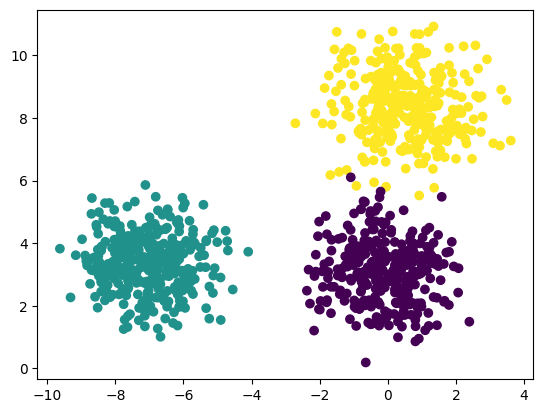

In [43]:
plt.scatter(x[:,0],x[:,1],c=y)    # c=color

In [44]:
## standardization---feature scaling technique
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [45]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.33,random_state=42)

In [46]:
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

In [47]:
from sklearn.cluster import KMeans

In [48]:
## Elbow method to select K value
wcss=[]        # Within-Cluster Sum of Squares
for k in range (1,11):
    kmeans=KMeans(n_clusters=k,init="k-means++")
    kmeans.fit(x_train_scaled)
    wcss.append(kmeans.inertia_)

In [49]:
wcss

[1339.9999999999993,
 569.492016188313,
 148.4081368587047,
 123.89305668187991,
 119.90663170691307,
 94.09119824561607,
 78.13317024684073,
 70.99792211894166,
 65.0131994263699,
 58.99682518549546]

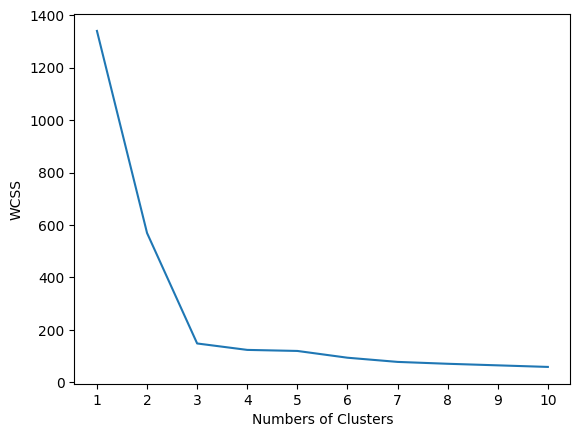

In [50]:
## plot elbow curve
plt.plot(range(1,11),wcss)
plt.xticks(range(1,11))
plt.xlabel("Numbers of Clusters")
plt.ylabel("WCSS")
plt.show()

In [51]:
kmeans=KMeans(n_clusters=3,init="k-means++")

In [52]:
kmeans.fit_predict(x_train_scaled)

array([1, 1, 0, 1, 2, 0, 2, 1, 2, 1, 1, 0, 0, 2, 0, 1, 0, 2, 0, 0, 1, 1,
       0, 1, 1, 0, 2, 0, 0, 0, 1, 1, 2, 2, 1, 0, 1, 1, 2, 1, 2, 2, 2, 1,
       0, 0, 1, 0, 2, 2, 0, 1, 0, 2, 2, 2, 1, 2, 1, 2, 1, 0, 1, 0, 0, 2,
       1, 0, 2, 2, 0, 0, 0, 1, 1, 2, 2, 0, 1, 1, 2, 2, 0, 2, 0, 1, 0, 0,
       1, 0, 0, 0, 0, 1, 0, 0, 2, 2, 1, 1, 2, 2, 1, 0, 2, 0, 1, 1, 1, 1,
       2, 1, 0, 2, 1, 2, 1, 2, 2, 0, 2, 2, 2, 1, 2, 0, 2, 0, 2, 1, 0, 1,
       0, 0, 1, 1, 1, 2, 0, 0, 0, 2, 0, 1, 1, 0, 0, 0, 1, 0, 0, 2, 2, 2,
       0, 0, 2, 0, 1, 2, 2, 1, 1, 2, 1, 1, 2, 1, 1, 0, 1, 2, 1, 0, 1, 2,
       2, 2, 0, 2, 2, 1, 0, 1, 0, 0, 1, 1, 2, 1, 0, 0, 2, 1, 1, 0, 2, 2,
       0, 0, 2, 0, 2, 1, 0, 2, 0, 1, 0, 0, 2, 1, 1, 0, 0, 1, 2, 1, 1, 0,
       0, 1, 0, 2, 1, 2, 2, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 2, 2, 0, 0, 0,
       0, 0, 2, 2, 1, 1, 1, 2, 1, 0, 0, 1, 0, 1, 0, 0, 2, 0, 0, 0, 2, 0,
       2, 0, 0, 0, 2, 1, 2, 2, 2, 2, 0, 0, 2, 1, 1, 0, 1, 0, 2, 0, 0, 0,
       0, 2, 2, 1, 0, 2, 0, 0, 1, 2, 2, 0, 1, 0, 0,

In [53]:
y_pred=kmeans.predict(x_test_scaled)

In [54]:
y_pred

array([0, 1, 1, 2, 1, 2, 1, 2, 1, 0, 2, 2, 2, 1, 2, 2, 0, 2, 1, 1, 1, 2,
       0, 0, 1, 1, 2, 0, 2, 0, 2, 1, 2, 1, 1, 1, 0, 0, 0, 1, 0, 0, 2, 2,
       0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 2, 0, 1, 1, 2, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 1, 1, 2, 2, 0, 2, 1, 1, 2, 2, 2, 2, 0, 0, 1, 2, 1, 1, 1, 0,
       0, 1, 2, 0, 0, 1, 0, 0, 2, 2, 2, 0, 1, 2, 2, 1, 2, 0, 1, 0, 2, 0,
       2, 1, 1, 1, 0, 1, 2, 1, 1, 1, 1, 0, 0, 2, 0, 0, 0, 1, 1, 2, 2, 1,
       0, 2, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 2, 0, 1, 1, 1, 2, 2, 0, 2, 2,
       0, 2, 2, 2, 0, 0, 2, 0, 2, 2, 1, 2, 1, 0, 2, 2, 0, 1, 0, 0, 2, 1,
       2, 0, 2, 2, 0, 0, 0, 2, 1, 1, 1, 2, 0, 2, 2, 1, 0, 1, 1, 2, 2, 2,
       0, 1, 0, 2, 2, 0, 1, 2, 0, 1, 0, 2, 2, 1, 1, 1, 2, 2, 0, 0, 2, 1,
       0, 1, 0, 2, 2, 2, 1, 0, 2, 2, 0, 1, 2, 2, 0, 1, 1, 1, 1, 1, 2, 2,
       0, 0, 1, 1, 1, 1, 2, 2, 1, 2, 0, 0, 2, 1, 2, 2, 2, 0, 2, 1, 0, 0,
       1, 1, 0, 1, 1, 0, 0, 2, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 2, 0, 0, 1,
       2, 2, 1, 2, 1, 2, 0, 0, 2, 2, 0, 2, 1, 1, 1,

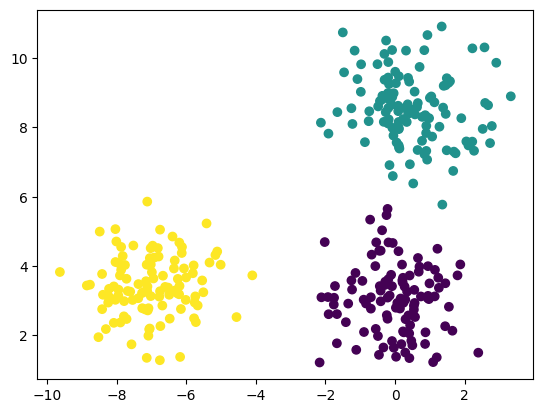

In [55]:
plt.scatter(x_test[:,0],x_test[:,1],c=y_pred)

In [56]:
## validating the k value
## kneelocator
## silhoutee scoring

In [57]:
## kneelocator
!pip install kneed


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [58]:
from kneed import KneeLocator

In [59]:
kl = KneeLocator(range(1, 11), wcss, curve='convex', direction='decreasing')

In [60]:
kl.elbow

np.int64(3)

In [61]:
## silhoutee scoring
from sklearn.metrics import silhouette_score

In [62]:
silhouette_coefficients=[]
for k in range(2,11):
    kmeans=KMeans(n_clusters=k,init="k-means++")
    kmeans.fit(x_train_scaled)
    score=silhouette_score(x_train_scaled,kmeans.labels_)
    silhouette_coefficients.append(score)

In [63]:
silhouette_coefficients

[0.537446438238467,
 0.6914853039765887,
 0.5763678503509707,
 0.44693541724311553,
 0.4636698696493342,
 0.353774446398644,
 0.3247141552901229,
 0.3223936482782796,
 0.3330979834004143]

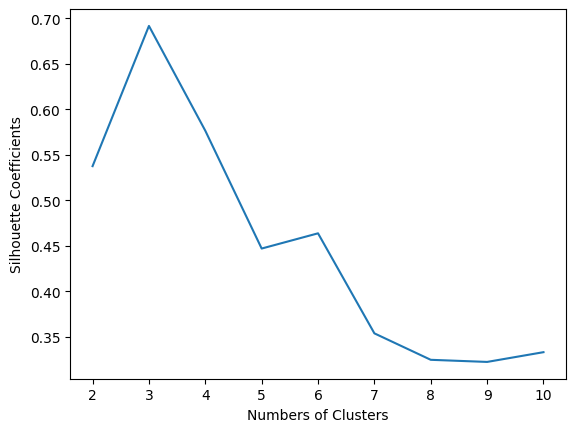

In [64]:
## plot silhouette_score
plt.plot(range(2,11),silhouette_coefficients)
plt.xticks(range(2,11))
plt.xlabel("Numbers of Clusters")
plt.ylabel("Silhouette Coefficients")
plt.show()